<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/tensorflow_with_builtin_layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def load_and_prepare_data(test_size: float = 0.2, val_size: float = 0.2, seed: int = 42):
    """
    Load California Housing, split into train/val/test, scale features using StandardScaler.

    Args:
        test_size: Fraction for test split (from full data).
        val_size: Fraction for validation split (from train portion).
        seed: Random seed.

    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test as np.float32 arrays.
    """
    data = fetch_california_housing()
    X = data.data
    y = data.target.reshape(-1, 1)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return (
        X_train.astype(np.float32),
        y_train.astype(np.float32),
        X_val.astype(np.float32),
        y_val.astype(np.float32),
        X_test.astype(np.float32),
        y_test.astype(np.float32),
    )


X_train, y_train, X_val, y_val, X_test, y_test = load_and_prepare_data()
input_size = X_train.shape[1]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 10/200  Train MSE: 0.3303  Val MSE: 0.3532
Epoch 20/200  Train MSE: 0.2907  Val MSE: 0.3241
Epoch 30/200  Train MSE: 0.2702  Val MSE: 0.3028
Epoch 40/200  Train MSE: 0.2569  Val MSE: 0.3035
Epoch 50/200  Train MSE: 0.2488  Val MSE: 0.2936
Epoch 60/200  Train MSE: 0.2366  Val MSE: 0.2930
Epoch 70/200  Train MSE: 0.2297  Val MSE: 0.2827
Epoch 80/200  Train MSE: 0.2246  Val MSE: 0.2807
Epoch 90/200  Train MSE: 0.2169  Val MSE: 0.2873
Epoch 100/200  Train MSE: 0.2123  Val MSE: 0.2901
Epoch 110/200  Train MSE: 0.2058  Val MSE: 0.2914
Epoch 120/200  Train MSE: 0.2065  Val MSE: 0.2795
Epoch 130/200  Train MSE: 0.2023  Val MSE: 0.2912
Epoch 140/200  Train MSE: 0.1952  Val MSE: 0.2910
Epoch 150/200  Train MSE: 0.1883  Val MSE: 0.2886
Epoch 160/200  Train MSE: 0.1872  Val MSE: 0.2989
Epoch 170/200  Train MSE: 0.1816  Val MSE: 0.2886
Epoch 180/200  Train MSE: 0.1762  Val MSE: 0.2921
Epoch 190/200  Train MSE: 0.1794  Val MSE: 0.2957
Epoch 200/200  Train MSE: 0.1723  Val MSE: 0.2979
Test MSE:

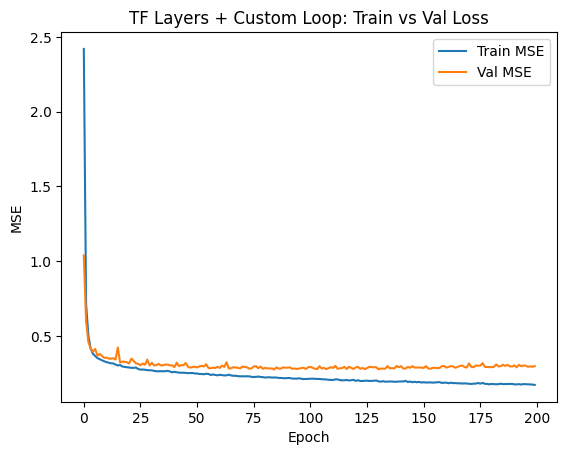

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt


class DeepNN(tf.keras.Model):
    def __init__(self, input_size: int):
        """
        Deep regressor using built-in Keras layers, trained via custom loop.

        Args:
            input_size: Number of input features.
        """
        super().__init__()
        self.fc1 = tf.keras.layers.Dense(64, activation="relu", input_shape=(input_size,))
        self.fc2 = tf.keras.layers.Dense(64, activation="relu")
        self.fc3 = tf.keras.layers.Dense(64, activation="relu")
        self.out = tf.keras.layers.Dense(1)

    def call(self, x: tf.Tensor, training: bool = False) -> tf.Tensor:
        """
        Forward pass.

        Args:
            x: Input tensor (batch, input_size).
            training: Training flag (not used here).
        Returns:
            Output tensor (batch, 1).
        """
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return self.out(x)


model = DeepNN(input_size)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

batch_size = 256
epochs = 200

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10_000).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    train_mean = tf.keras.metrics.Mean()
    val_mean = tf.keras.metrics.Mean()

    # Train
    for xb, yb in train_ds:
        with tf.GradientTape() as tape:
            preds = model(xb, training=True)
            loss = tf.reduce_mean(tf.square(preds - yb))
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_mean.update_state(loss)

    # Val
    for xb, yb in val_ds:
        preds = model(xb, training=False)
        loss = tf.reduce_mean(tf.square(preds - yb))
        val_mean.update_state(loss)

    tr = float(train_mean.result().numpy())
    va = float(val_mean.result().numpy())
    train_losses.append(tr)
    val_losses.append(va)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}  Train MSE: {tr:.4f}  Val MSE: {va:.4f}")

# Test
test_preds = model(X_test, training=False)
test_mse = float(tf.reduce_mean(tf.square(test_preds - y_test)).numpy())
print("Test MSE:", test_mse)

plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Val MSE")
plt.title("TF Layers + Custom Loop: Train vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()